### TMT Telco Churn Save Multi Agent

In [1]:
# !pip install -q langgraph langchain-openai langchain-core

In [2]:
import os, json, getpass
from typing import TypedDict, Optional, Annotated
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# ----------------------------------------------------------------------------
# STRATEGY: Temperature 0 isn't a style choice here, it's a governance one.
# A churn-save system makes money decisions on real subscribers. If the same
# subscriber could get a $0 offer on Monday and a 30%-off offer on Tuesday
# because the model sampled differently, you can't defend the decision to a
# commercial review board, and you can't run a clean eval. Determinism in the
# judgment layer is what makes the system auditable and the A/B tests valid.
# ============================================================================

from langchain_openai import ChatOpenAI
LLM = ChatOpenAI(model="gpt-4.1-mini", temperature=0) 
# we want a model that has temperature = 0, make sure to check if 4.1 mini is available to you, 
# otherwise use the most advanced model you have access to with temperature = 0


In [4]:
# ============================================================================
# CELL 2 — APPROVED OFFER CATALOG + SYNTHETIC AT-RISK SUBSCRIBERS
# ----------------------------------------------------------------------------
# STRATEGY: The catalog is not "config." It is the retention P&L written as
# data. Every field maps to a lever the commercial team actually owns:
#   - monthly_cost_to_serve  -> what this offer costs the telco per month
#   - eligibility            -> who marketing has DECIDED is allowed to receive it
#   - regulatory_notes       -> the compliance constraint the regulator owns
# Encoding policy as data (not prose, not prompt) means changing policy is a
# data edit a non-engineer can review and approve — that's how a retention
# program actually governs itself. The LLM never sees these numbers; it only
# ever sees the SHORTLIST this policy produces. That separation is the whole
# architecture.
# ============================================================================

OFFER_CATALOG = {
    "NO_OFFER": {
        # STRATEGY: NO_OFFER is a first-class action, not the absence of one.
        # The single biggest waste in retention is spending money on people who
        # would have stayed anyway. Making "do nothing" an explicit, selectable
        # offer is what lets the system CHOOSE restraint instead of defaulting to spend.
        "name": "No proactive offer",
        "monthly_cost_to_serve": 0.0, "term_months": 0, "one_time_cost": 0.0,
        "eligibility": {}, "regulatory_notes": "n/a",
        "description": "Take no retention action; log and monitor.",
    },
    "LOYALTY_PERK": {
        # STRATEGY: The cheap goodwill lever. Low cost, no contract change, so it's
        # the right tool when you want to acknowledge a wavering-but-low-stakes
        # subscriber without burning margin. min_tenure 6mo because perks reward
        # loyalty you can actually see.
        "name": "Loyalty perk (data boost / streaming add-on)",
        "monthly_cost_to_serve": 4.0, "term_months": 6, "one_time_cost": 0.0,
        "eligibility": {"min_tenure_months": 6},
        "regulatory_notes": "Add-on must be cancellable; no auto-renew lock.",
        "description": "Low-cost goodwill perk, no contract change.",
    },
    "BILL_CREDIT_SMALL": {
        # STRATEGY: A direct economic offer — straight margin out the door. Use it
        # when the risk driver is price/value, not service. The flat $10 cost means
        # it hits low-ARPU subscribers HARD as a % of their value (you'll see this
        # bite S004 in Cell 4). That's intentional realism, not a flaw.
        "name": "$10/mo bill credit (6 mo)",
        "monthly_cost_to_serve": 10.0, "term_months": 6, "one_time_cost": 0.0,
        "eligibility": {"min_tenure_months": 3},
        "regulatory_notes": "Credit value must be disclosed; no clawback.",
        "description": "Modest recurring credit.",
    },
    "PLAN_UPGRADE_HOLD": {
        # STRATEGY: The "give more, charge the same" lever. Cheaper to the telco
        # than a cash credit of equal perceived value because incremental data/
        # features cost less than face value — this is why upgrades are a favorite
        # retention tool: high perceived value, lower true cost. Mid-tier intervention.
        "name": "Plan upgrade at current price (12 mo)",
        "monthly_cost_to_serve": 12.0, "term_months": 12, "one_time_cost": 0.0,
        "eligibility": {"min_tenure_months": 6, "requires_in_contract": False},
        "regulatory_notes": "Must honor price-lock for full term per advertised T&Cs.",
        "description": "More data/features at same price; mid-tier intervention.",
    },
    "RETENTION_DISCOUNT_AGGRESSIVE": {
        # STRATEGY: The "fight to keep them" lever, reserved for genuine port-out.
        # cost_is_pct_of_arpu=True is the most important modeling choice in the file:
        # a 30% discount costs MORE in absolute dollars the more valuable the
        # subscriber is. That's the real-world paradox of retention — the customers
        # most worth saving are the most expensive to save aggressively, and a
        # percentage discount can blow through a percentage margin floor on exactly
        # those high-value accounts (watch S003 in Cell 4).
        "name": "30% off for 12 months",
        "monthly_cost_to_serve": 0.30, "term_months": 12, "one_time_cost": 0.0,
        "eligibility": {"min_tenure_months": 12},
        "regulatory_notes": "Discount % of ARPU; must auto-expire with clear end-date disclosure.",
        "description": "Aggressive, bounded win-back for genuine port-out risk.",
        "cost_is_pct_of_arpu": True,
    },
    "DEVICE_UPGRADE_SUBSIDY": {
        # STRATEGY: The "re-lock them in" lever. High one-time cost, but it BUYS A
        # NEW CONTRACT — which converts a mobile out-of-contract subscriber back
        # into a switching-cost-protected one. You're not just discounting, you're
        # purchasing future stickiness. Amortized over 24mo because that's the
        # commitment the subsidy buys.
        "name": "Device upgrade subsidy ($150 one-time)",
        "monthly_cost_to_serve": 0.0, "term_months": 24, "one_time_cost": 150.0,
        "eligibility": {"min_tenure_months": 18, "requires_in_contract": False},
        "regulatory_notes": "New 24-mo commitment must be explicit & opt-in.",
        "description": "High one-time cost; requires re-contracting.",
    },
}

# STRATEGY: Three constants, three different owners.
# MARGIN_FLOOR_PCT is FINANCE's line — below this, saving the subscriber destroys value.
# BASELINE_MARGIN_PCT is the starting profitability the retention spend eats into.
# REG_MAX_DISCOUNT_PCT is the REGULATOR's / legal's line — independent of profit.
# Keeping them separate matters: a margin block is a business decision you can
# override with approval; a regulatory block is one you cannot. Cell 4 treats them
# as independent gates for exactly this reason.
MARGIN_FLOOR_PCT     = 0.45
BASELINE_MARGIN_PCT  = 0.70
REG_MAX_DISCOUNT_PCT = 0.35

# STRATEGY: These 7 aren't random. Each is a distinct commercial archetype the
# triage system MUST handle differently — if the system gives them all similar
# treatment, it has failed. The spread is the test.
SUBSCRIBERS = [
    # S001 — High value, OUT of contract, sniffing competitors. Worth fighting for,
    # genuinely mobile (no switching cost protecting you). The "deserves a real offer" case.
    {"subscriber_id": "S001", "tenure_months": 48, "plan_type": "premium_unlimited",
     "monthly_arpu": 95.0, "churn_risk_score": 0.82, "contract_status": "out_of_contract",
     "recent_signals": ["competitor_inquiry", "data_usage_drop"]},

    # S002 — New, LOW risk, flagged on ONE noisy signal. The deadweight-cost trap:
    # the model surfaced them, but they'd likely stay anyway. Spending here is pure loss.
    {"subscriber_id": "S002", "tenure_months": 3, "plan_type": "basic",
     "monthly_arpu": 25.0, "churn_risk_score": 0.31, "contract_status": "in_contract",
     "recent_signals": ["data_usage_drop"]},

    # S003 — Highest value, highest risk, multiple port-out signals, OUT of contract.
    # The case that most "deserves" the aggressive offer — and the one where the
    # margin floor fights back hardest. This is where strategy gets uncomfortable.
    {"subscriber_id": "S003", "tenure_months": 60, "plan_type": "premium_unlimited",
     "monthly_arpu": 88.0, "churn_risk_score": 0.91, "contract_status": "out_of_contract",
     "recent_signals": ["competitor_inquiry", "support_complaints", "data_usage_drop"]},

    # S004 — LOW ARPU, high risk, out of contract. The hard truth: at $18 ARPU,
    # most paid offers destroy more value than the subscriber is worth. Sometimes
    # the commercially correct answer is to let them go.
    {"subscriber_id": "S004", "tenure_months": 14, "plan_type": "value",
     "monthly_arpu": 18.0, "churn_risk_score": 0.74, "contract_status": "out_of_contract",
     "recent_signals": ["competitor_inquiry"]},

    # S005 — Mid value, IN contract, churning over SERVICE complaints, not price.
    # A discount may not fix this at all — the driver is service quality. Tests
    # whether the system reads the DRIVER, not just the score.
    {"subscriber_id": "S005", "tenure_months": 9, "plan_type": "standard",
     "monthly_arpu": 55.0, "churn_risk_score": 0.68, "contract_status": "in_contract",
     "recent_signals": ["support_complaints", "support_complaints"]},

    # S006 — Very new, very low risk. Almost certainly a false flag. The clearest
    # NO_OFFER case — if the system can't get this one right, it can't be trusted.
    {"subscriber_id": "S006", "tenure_months": 2, "plan_type": "basic",
     "monthly_arpu": 30.0, "churn_risk_score": 0.22, "contract_status": "in_contract",
     "recent_signals": ["support_complaints"]},

    # S007 — High risk, competitor inquiry, but still IN contract. The contract IS
    # your retention asset here — they face an early-termination cost to leave, so
    # you can afford to be more conservative than with S001/S003.
    {"subscriber_id": "S007", "tenure_months": 30, "plan_type": "standard",
     "monthly_arpu": 60.0, "churn_risk_score": 0.79, "contract_status": "in_contract",
     "recent_signals": ["competitor_inquiry", "data_usage_drop"]},
]

print(f"{len(OFFER_CATALOG)} offers, {len(SUBSCRIBERS)} subscribers loaded.")

6 offers, 7 subscribers loaded.


In [5]:
# ============================================================================
# CELL 3 — GRAPH STATE
# ----------------------------------------------------------------------------
# STRATEGY: State design is governance design. Notice the order the fields fill:
# eligibility_scan and approved_offers (the DETERMINISTIC policy result) are
# computed and frozen BEFORE offer_decision (the LLM's pick) ever exists. The
# state structure physically enforces "policy first, judgment second." The LLM
# literally cannot run before the guardrail has produced its shortlist.
#
# The 'trace' reducer is your audit trail. In a regulated commercial program you
# will be asked "why did this subscriber get this offer?" — the same explainability
# bar that examiners impose on KYC dispositions. trace appends one breadcrumb per
# node so every decision carries its own paper trail, no extra logging code.
# ============================================================================
def append_reducer(a, b):
    return (a or []) + (b or [])

class SaveState(TypedDict):
    subscriber:       dict
    eligibility_scan: Optional[dict]   # deterministic per-offer result (the policy ruling)
    approved_offers:  Optional[list]   # the shortlist the LLM is allowed to choose from
    offer_decision:   Optional[dict]   # {offer_key, rationale} — the judgment call
    message:          Optional[str]    # the customer- or ops-facing artifact
    trace:            Annotated[list, append_reducer]

print("SaveState defined.")

SaveState defined.


In [6]:
# ============================================================================
# CELL 4 — ELIGIBILITY + MARGIN AGENT  (DETERMINISTIC — the hard guardrail)
# ----------------------------------------------------------------------------
# STRATEGY: This is the agent finance and legal trust, because it has no judgment
# and no creativity — it applies policy arithmetic and nothing else. Its entire
# job is to shrink the action space to "things we are allowed to do," so that no
# downstream judgment, however clever, can spend below the floor or breach a reg.
# In retention, the costliest errors aren't bad talk-tracks — they're margin-
# destroying offers handed out at scale. This cell makes those errors impossible
# rather than merely unlikely.
# ============================================================================

def offer_monthly_cost(offer_key, arpu):
     # STRATEGY: % -of-ARPU offers cost more on valuable subscribers. Resolving the
    # real dollar cost HERE (not in the prompt) means the economics are computed
    # by code that can't be argued with, not inferred by a model that can.
    offer = OFFER_CATALOG[offer_key]
    if offer.get("cost_is_pct_of_arpu"):
        return round(offer["monthly_cost_to_serve"] * arpu, 2)
    return offer["monthly_cost_to_serve"]

def amortized_monthly_cost(offer_key, arpu):
    # STRATEGY: A $150 one-time subsidy isn't a $150 monthly hit. Spreading it over
    # the contract it buys is how the telco actually books the cost — and only the
    # amortized number can be compared fairly against a recurring credit.
    offer = OFFER_CATALOG[offer_key]
    monthly_cost = offer_monthly_cost(offer_key, arpu)
    if offer.get("one_time_cost") and offer.get("term_months"):
        monthly_cost += round(offer["one_time_cost"] / offer["term_months"], 2)
    return monthly_cost

def check_offer(offer_key, sub):
    offer = OFFER_CATALOG[offer_key]
    elig = offer["eligibility"]
    arpu = sub["monthly_arpu"]

    reasons = []

    # GATE 1 — ELIGIBILITY (marketing's rules): is this subscriber even allowed this offer?
    eligible = True

    if "min_tenure_months" in elig and sub["tenure_months"] < elig["min_tenure_months"]:
        eligible = False
        reasons.append(f"tenure {sub['tenure_months']} mo < required {elig['min_tenure_months']} mo")
    
    if elig.get("requires_in_contract") is True and sub["contract_status"] != "in_contract":
        eligible = False
        reasons.append(f"requires in-contract status")

    # GATE 2 — MARGIN FLOOR (finance's rule): does saving them still leave us profitable?
    # STRATEGY: retained margin = starting profit minus what the offer costs, as a %
    # of ARPU. Below the floor, you're paying more to keep the subscriber than they're
    # worth — a "save" that loses money. This is the line that makes the system say no
    # to offers it WANTS to make on high-value accounts (see S003 below).

    monthly_cost = amortized_monthly_cost(offer_key, arpu)
    retained_margin_pct = (arpu * BASELINE_MARGIN_PCT - monthly_cost) / arpu if arpu != 0 else 0
    margin_ok = retained_margin_pct >= MARGIN_FLOOR_PCT

    if not margin_ok:
        reasons.append(f"retained margin {retained_margin_pct:.0%} < floor {MARGIN_FLOOR_PCT:.0%}"
                    f" (cost ${monthly_cost}/mo on ${arpu} ARPU)")

    # Gate 3 - Regulatory Cap (legal's rule): independent of profit. A discount can be 
    # wildly profitable and still illegal/non-compliant. Separate gate, separate owner.
    reg_ok = True
    if offer.get("cost_is_pct_of_arpu") and offer["monthly_cost_to_serve"] > REG_MAX_DISCOUNT_PCT:
        reg_ok = False
        reasons.append(f"discount {offer['monthly_cost_to_serve']:.0%} of ARPU > regulatory max {REG_MAX_DISCOUNT_PCT:.0%}")

    
    # approved only if ALL THREE owners agree. One veto kills the offer.

    return {"offer_key": offer_key, "eligible": eligible, "margin_ok": margin_ok, 
    "reg_ok": reg_ok, "approved": eligible and margin_ok and reg_ok,
    "monthly_cost": monthly_cost, "retained_margin_pct": round(retained_margin_pct, 3), "reasons": reasons}


## This is where the eligibility margin node for the agent graph is created 
def eligibility_margin_node(state: SaveState) -> SaveState:
    sub = state["subscriber"]
    scan_results = {}
    for offer_key in OFFER_CATALOG.keys():
        scan_results[offer_key] = check_offer(offer_key, sub)
    
    approved_offers = [offer for offer, result in scan_results.items() if result["approved"]]

    return {"eligibility_scan": scan_results, "approved_offers": approved_offers,
            "trace": [f"EligibilityMargin[{sub['subscriber_id']}]: approved {approved_offers}"]}

# --- Run by hand against all 7 BEFORE wiring any LLM. The shortlist per subscriber
#     IS the strategy made visible. A wide list = lots of room to maneuver; a list
#     of just ['NO_OFFER'] = policy has already decided this subscriber isn't worth saving.
for sub in SUBSCRIBERS:
    scan = {k: check_offer(k, sub) for k in OFFER_CATALOG}
    approved = [k for k, v in scan.items() if v["approved"]]
    print(f"{sub['subscriber_id']} (ARPU ${sub['monthly_arpu']}, risk {sub['churn_risk_score']}, "
          f"{sub['contract_status']}): {approved}")

# STRATEGY PAYOFF: S003 is the highest-value port-out risk — exactly who you'd want
# to throw the aggressive discount at. But 30% of $88 = $26.40/mo, which drops retained
# margin to 40%, under the 45% floor. The system you built REFUSES to over-spend even
# on your best customer. That tension — "most worth saving, too expensive to save the
# aggressive way" — is the central lesson of retention pricing. Decide consciously:
# let the floor hold (default), or add a documented manager-approval override for
# genuine port-out. Don't punch the hole until you've felt why the wall is there.
print("\nS003 aggressive-discount detail:",
      check_offer("RETENTION_DISCOUNT_AGGRESSIVE", SUBSCRIBERS[2])["reasons"])




S001 (ARPU $95.0, risk 0.82, out_of_contract): ['NO_OFFER', 'LOYALTY_PERK', 'BILL_CREDIT_SMALL', 'PLAN_UPGRADE_HOLD', 'DEVICE_UPGRADE_SUBSIDY']
S002 (ARPU $25.0, risk 0.31, in_contract): ['NO_OFFER']
S003 (ARPU $88.0, risk 0.91, out_of_contract): ['NO_OFFER', 'LOYALTY_PERK', 'BILL_CREDIT_SMALL', 'PLAN_UPGRADE_HOLD', 'DEVICE_UPGRADE_SUBSIDY']
S004 (ARPU $18.0, risk 0.74, out_of_contract): ['NO_OFFER', 'LOYALTY_PERK']
S005 (ARPU $55.0, risk 0.68, in_contract): ['NO_OFFER', 'LOYALTY_PERK', 'BILL_CREDIT_SMALL', 'PLAN_UPGRADE_HOLD']
S006 (ARPU $30.0, risk 0.22, in_contract): ['NO_OFFER']
S007 (ARPU $60.0, risk 0.79, in_contract): ['NO_OFFER', 'LOYALTY_PERK', 'BILL_CREDIT_SMALL', 'PLAN_UPGRADE_HOLD', 'DEVICE_UPGRADE_SUBSIDY']

S003 aggressive-discount detail: ['retained margin 40% < floor 45% (cost $26.4/mo on $88.0 ARPU)']


In [7]:
# ============================================================================
# CELL 5 — OFFER MATCH AGENT  (LLM JUDGMENT — bounded)
# ----------------------------------------------------------------------------
# STRATEGY: This is where the system earns its ROI. Two retention philosophies:
# (a) blanket the at-risk list with discounts — simple, expensive, leaks margin
#     on everyone who'd have stayed; or
# (b) match the CHEAPEST EFFECTIVE intervention to each subscriber's real risk
#     driver — harder, requires judgment, but it's the entire profit case for
#     putting an LLM here instead of a rules table.
# The prompt is doing strategy, not generation: "don't over-discount someone who'd
# stay" is the deadweight-cost discipline; "address the DRIVER" is the insight that
# a service complaint isn't fixed by a price cut. And critically — the model only
# ever picks from the approved shortlist, so its judgment can shape SPEND EFFICIENCY
# but can never breach the guardrail. Bounded autonomy.
# ============================================================================

OFFER_MATCH_SYSTEM = """You are a telco retention strategist. Pick the single CHEAPEST EFFECTIVE \
save offer for an at-risk subscriber, choosing ONLY from the approved offers provided.

Core principles:
- Match intervention strength to genuine churn risk AND its driver.
- DO NOT over-discount someone who would likely stay anyway. A noisy single signal on a low-risk, \
short-tenure subscriber usually warrants NO_OFFER — paying to retain them is pure deadweight cost.
- Address the risk DRIVER: a price-sensitive competitor-inquiry case responds to economic offers; a \
service-complaint case may not be fixed by a discount at all.
- Out-of-contract + high risk + competitor inquiry = genuine port-out; use the strongest APPROVED offer.
- In-contract subscribers already face switching friction; be more conservative.
- Prefer the lowest-cost offer that plausibly changes the outcome.

Respond with ONLY a JSON object, no markdown, no prose:
{"offer_key": "<one of the approved keys>", "rationale": "<=2 sentences tying choice to risk driver and cost>"}"""


def offer_match_node(state: SaveState) -> SaveState:
    sub = state["subscriber"]
    scan = state["eligibility_scan"]
    approved = state["approved_offers"]

    # STRATEGY: we hand the model the offer COST alongside each option, because
    # "cheapest effective" is a cost-aware judgment. We do NOT hand it the margin
    # floor — that decision is already made. The model optimizes within the allowed
    # set; it doesn't get to relitigate what's allowed.

    approved_detail = {
        k: {"name": OFFER_CATALOG[k]["name"], 
        "monthly_cost": scan[k]["monthly_cost"],
        "addresses": OFFER_CATALOG[k]["description"]} 
        for k in approved
    }

    user = f"""SUBSCRIBER:
        id: {sub['subscriber_id']}
        tenure_months: {sub['tenure_months']}
        plan_type: {sub['plan_type']}
        monthly_arpu: {sub['monthly_arpu']}
        churn_risk_score: {sub['churn_risk_score']} (0-1, higher = more likely to leave)
        contract_status: {sub['contract_status']}
        recent_signals: {sub['recent_signals']}

        APPROVED OFFERS (you MUST pick one of these keys):
        {json.dumps(approved_detail, indent=2)}
    """

    resp = LLM.invoke([("system", OFFER_MATCH_SYSTEM), ("user", user)])
    raw = resp.content.strip().replace("```json", "").replace("```", "").strip()  # strip markdown if any

    # STRATEGY: defense in depth. Even though the prompt constrains the model, we
    # re-verify the pick against the approved set. If it ever hallucinates an offer,
    # we fall back to NO_OFFER — the safe action is always the cheap action. The
    # guardrail holds even when the model misbehaves.

    try:
        dec = json.loads(raw)
        if dec.get("offer_key") not in approved:
            dec = {"offer_key": "NO_OFFER",
                   "rationale": f"LLM picked non-approved key; safe fallback. (raw: {dec.get('offer_key')})"}

    except Exception as e:
        dec = {"offer_key": "NO_OFFER",
               "rationale": f"LLM response parse error; safe fallback. (error: {str(e)}, raw: {raw})"}

    return {"offer_decision": dec,
            "trace": [f"OfferMatch[{sub['subscriber_id']}]: {dec['offer_key']} - {dec['rationale']}"]}

print("offerMatchAgent defined")


offerMatchAgent defined


In [8]:
# ============================================================================
# CELL 6 — MESSAGE AGENT  (LLM GENERATION — compliant drafting)
# ----------------------------------------------------------------------------
# STRATEGY: The decision is made; this turns it into something a frontline rep or
# an outbound channel can actually use. Two commercial realities are encoded here:
# (1) Compliance is a brand and legal risk, not a nicety — the offer's regulatory
#     notes (disclose end-dates, opt-in for re-contracting) flow into the draft so
#     the promise made to the customer matches the promise the policy allows.
# (2) NO_OFFER must NEVER produce customer-facing copy. "We've decided not to help
#     you" is the worst possible message to send. For NO_OFFER we emit an INTERNAL
#     ops note instead — the action is "monitor," and only the ops team should see it.
# ============================================================================
MESSAGE_SYSTEM = """You draft telco retention communications. Output must be:
- Warm, concise, brand-neutral (no specific brand name).
- COMPLIANT: respect the regulatory notes for the offer in spirit (disclose terms, end-dates, opt-in).
- Honest: never imply scarcity/urgency that isn't real; never promise beyond the offer terms.

If the offer is NO_OFFER, output an INTERNAL monitoring note for the ops team (not customer-facing), \
prefixed with [INTERNAL].

Output the message text only — no preamble, no quotes."""


def message_node(state: SaveState):
    sub = state["subscriber"]
    dec = state["offer_decision"]
    offer = OFFER_CATALOG[dec["offer_key"]]

    # STRATEGY: passing the rationale and the risk signals into the drafting step
    # lets the message SPEAK TO THE DRIVER — a port-out case and a loyalty case
    # should not read the same. The talk-track is more persuasive when it addresses
    # why the subscriber is actually wavering.

    user = f"""Offer chosen: {offer['name']} (key: {dec['offer_key']})
            Offer description: {offer['description']}
            Regulatory notes to honor: {offer['regulatory_notes']}
            Why this offer: {dec['rationale']}
            Subscriber tenure: {sub['tenure_months']} months
            Risk driver signals: {sub['recent_signals']}

            Draft the {'INTERNAL monitoring note' if dec['offer_key']=='NO_OFFER' else 'retention talk-track / outbound message'}."""
    resp = LLM.invoke([("system", MESSAGE_SYSTEM), ("user", user)])
    msg = resp.content.strip()

    return {"message": msg, "trace": [f"Message[{sub['subscriber_id']}]: drafted ({len(msg)} chars)"]}

print("MessageAgent defined.")

MessageAgent defined.


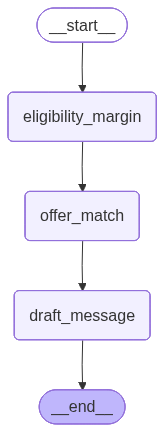

In [9]:
# ============================================================================
# CELL 7 — GRAPH WIRING
# ----------------------------------------------------------------------------
# STRATEGY: The topology IS the control structure. A strict linear order —
# policy gate -> bounded judgment -> compliant drafting — means the expensive,
# risky step (spending money) is always preceded by the step that constrains it.
# There are no conditional edges because the branching ("what's allowed") lives
# in the DATA the deterministic node emits, not in the graph. That's deliberate:
# changing what the system can do is a policy/data change a commercial owner can
# make, not a re-architecture an engineer has to ship.
# ============================================================================
from langgraph.graph import StateGraph, START, END

builder = StateGraph(SaveState)
builder.add_node("eligibility_margin", eligibility_margin_node)
builder.add_node("offer_match",        offer_match_node)
builder.add_node("draft_message", message_node)

builder.add_edge(START, "eligibility_margin")
builder.add_edge("eligibility_margin", "offer_match")
builder.add_edge("offer_match", "draft_message")
builder.add_edge("draft_message", END)

graph = builder.compile()

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [10]:
# ============================================================================
# CELL 8 — RUN LOOP
# ----------------------------------------------------------------------------
# STRATEGY: Read the output as a portfolio decision, not 7 isolated ones. A healthy
# retention program produces a SPREAD: some NO_OFFERs (restraint), some cheap perks,
# a few real interventions on the genuinely at-risk and valuable. If every subscriber
# gets a similar offer, the system isn't triaging — it's blanket-spending with extra
# steps. The differentiation across S001–S007 is the proof the strategy is working.
# ============================================================================
results = []
for sub in SUBSCRIBERS:
    out = graph.invoke({"subscriber": sub})
    results.append(out)
    dec = out["offer_decision"]
    print(f"\n{'='*72}")
    print(f"{sub['subscriber_id']}  |  ARPU ${sub['monthly_arpu']}  |  risk {sub['churn_risk_score']}  "
          f"|  {sub['contract_status']}  |  {sub['recent_signals']}")
    print(f"  -> OFFER: {dec['offer_key']}  ({OFFER_CATALOG[dec['offer_key']]['name']})")
    print(f"     why:   {dec['rationale']}")
    print(f"  -> MESSAGE:\n     " + out["message"].replace("\n", "\n     "))


S001  |  ARPU $95.0  |  risk 0.82  |  out_of_contract  |  ['competitor_inquiry', 'data_usage_drop']
  -> OFFER: BILL_CREDIT_SMALL  ($10/mo bill credit (6 mo))
     why:   High churn risk with competitor inquiry and out-of-contract status indicates genuine port-out risk; a $10/mo bill credit is the cheapest effective economic incentive to retain this price-sensitive subscriber.
  -> MESSAGE:
     We appreciate having you with us for the past 48 months. To thank you for your loyalty, we’re offering a $10 monthly credit on your bill for the next 6 months. This credit will be applied automatically—no action needed on your part. If you have any questions or want to discuss your plan options, we’re here to help.

S002  |  ARPU $25.0  |  risk 0.31  |  in_contract  |  ['data_usage_drop']
  -> OFFER: NO_OFFER  (No proactive offer)
     why:   Low churn risk and short tenure with no price sensitivity or competitor inquiry; data usage drop alone does not justify a costly offer.
  -> MESSAGE:
   

In [11]:
# ============================================================================
# CELL 9 — EVALUATION
# ----------------------------------------------------------------------------
# STRATEGY: Three metrics, ranked by what they protect — and notice none of them
# measures "did the subscriber stay." That's deliberate (Cell 10 explains why).
#   1. MARGIN-FLOOR VIOLATIONS — protects the P&L. Must be 0. This isn't a quality
#      score, it's a contract: the system promised finance it cannot overspend.
#      The assert turns that promise into a build-breaking failure if violated.
#   2. OVER-DISCOUNT ON LOW-RISK — the ROI lever. Every paid offer to a would-stay
#      subscriber is margin lit on fire. This is the number that justifies the LLM's
#      cost over a blanket-discount policy.
#   3. DIRECTIONAL APPROPRIATENESS — sanity that intervention strength tracks risk.
#      Coarse on purpose; the point is to catch gross misrouting, not to grade nuance.
# ============================================================================
LOW_RISK_THRESHOLD = 0.4

margin_violations, over_discounts, appropriate, low_risk_total = 0, 0, 0, 0
rows = []

for out in results:
    sub = out["subscriber"]; scan = out["eligibility_scan"]
    chosen = out["offer_decision"]["offer_key"]
    risk = sub["churn_risk_score"]; cost = scan[chosen]["monthly_cost"]

    # METRIC 1: re-check the chosen offer against the deterministic engine. Structurally
    # 0 (the LLM only picks approved offers), but we VERIFY rather than trust — a
    # guardrail you don't test is a guardrail you don't have.
    violated = not scan[chosen]["margin_ok"]
    margin_violations += int(violated)

    # METRIC 2: low-risk subscriber who got anything other than NO_OFFER = deadweight spend.
    is_low = risk < LOW_RISK_THRESHOLD
    low_risk_total += int(is_low)
    over = is_low and chosen != "NO_OFFER"
    over_discounts += int(over)

    # METRIC 3: did strength track risk? low risk -> NO_OFFER; genuine port-out -> a paid offer.
    if is_low:
        ok = chosen == "NO_OFFER"
    elif risk >= 0.8 and "competitor_inquiry" in sub["recent_signals"] and sub["contract_status"] == "out_of_contract":
        ok = cost > 0
    else:
        ok = True
    appropriate += int(ok)

    rows.append((sub["subscriber_id"], risk, sub["contract_status"], chosen, f"${cost}",
                 "VIOLATION" if violated else "ok",
                 "over-discount" if over else "-",
                 "appropriate" if ok else "QUESTION"))

print(f"{'ID':5}{'risk':6}{'contract':18}{'offer':32}{'cost':8}{'margin':12}{'low-risk':15}{'approp':12}")
for r in rows:
    print(f"{r[0]:5}{r[1]:<6}{r[2]:18}{r[3]:32}{r[4]:8}{r[5]:12}{r[6]:15}{r[7]:12}")

n = len(results)
print(f"\n{'-'*72}")
print(f"Margin-floor violations:        {margin_violations} / {n}   (HARD GUARDRAIL — must be 0)")
print(f"Over-discount on low-risk:      {over_discounts} / {low_risk_total} low-risk subs")
print(f"Directional appropriateness:    {appropriate} / {n}")
assert margin_violations == 0, "HARD GUARDRAIL BREACHED — investigate deterministic node."
print("\nHard guardrail holds. ✓")

ID   risk  contract          offer                           cost    margin      low-risk       approp      
S001 0.82  out_of_contract   BILL_CREDIT_SMALL               $10.0   ok          -              appropriate 
S002 0.31  in_contract       NO_OFFER                        $0.0    ok          -              appropriate 
S003 0.91  out_of_contract   BILL_CREDIT_SMALL               $10.0   ok          -              appropriate 
S004 0.74  out_of_contract   BILL_CREDIT_SMALL               $10.0   ok          -              appropriate 
S005 0.68  in_contract       LOYALTY_PERK                    $4.0    ok          -              appropriate 
S006 0.22  in_contract       LOYALTY_PERK                    $4.0    ok          over-discount  QUESTION    
S007 0.79  in_contract       LOYALTY_PERK                    $4.0    ok          -              appropriate 

------------------------------------------------------------------------
Margin-floor violations:        0 / 7   (HARD GUARDRAI